# 🧠 Detecting Auditory P300 with Deep Learning (EEGNet)

> 📄 Reference: Lawhern et al. (2018). *EEGNet: A Compact Convolutional Neural Network for EEG-based BCIs.* J. Neural Eng. https://arxiv.org/abs/1611.08024


## 1. Background

---

P300 is an event-related potential (ERP) — a brain signal that appears roughly 300 milliseconds after a participant detects a rare, task-relevant stimulus (Oddball Paradigm).

---
Oddball Paradigm is contain with 2 type of trial

- Standard Trial (1000 Hz) → frequent (~80%) → no P300
- Target Trial (2000 Hz) → rare (~20%) → P300 response!


## 2. Environment Setup -- Install & Import Necessary Libraries (This process would take a while)

In [1]:
!pip install torch numpy scipy matplotlib seaborn scikit-learn gradio -q

import numpy as np
import scipy.signal as signal
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, confusion_matrix,
                              roc_auc_score, roc_curve)

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset, WeightedRandomSampler
from torch.optim.lr_scheduler import CosineAnnealingLR

import warnings
warnings.filterwarnings('ignore')

Define SEED to fix the random data and select runtime type to GPU

In [2]:
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

## 3. Synthetic EEG Data Generation

P300 amplitude follows real 10-20 topography:  
- Pz (7 µV)
- P3/P4 (5 µV)
- Cz (3.5 µV)
- Fz (2 µV)

Set-up EEG Parameter (Amplitude and Channels) in 10-20 System by using EEGParams

In [3]:
class EEGParams:
    sfreq       = 256    # Sampling frequency (Hz)
    n_channels  = 21     # 19 standard 10-20 + 2 reference
    epoch_start = -0.2   # seconds before stimulus
    epoch_end   =  0.8   # seconds after  stimulus
    n_standard  = 800    # non-target trials
    n_target    = 200    # target (P300) trials with 20% ratio

    channel_names = [
        'Fp1', 'Fp2',                           # Prefrontal
        'F7',  'F3',  'Fz',  'F4',  'F8',       # Frontal
        'C3',  'Cz',  'C4',                     # Central
        'P3',  'Pz',  'P4',                     # Parietal
        'T3',  'T4',  'T5',  'T6',              # Temporal
        'O1',  'O2',                            # Occipital
        'M1',  'M2'                             # Reference
    ]

    # P300 peak amplitude per channel (µV)
    p300_amplitude = np.array([
        0.5,  0.5,                      # Fp1, Fp2  — Prefrontal
        0.8,  1.5,  2.0,  1.5,  0.8,    # F7, F3, Fz, F4, F8 — Frontal
        2.5,  3.5,  2.5,                # C3, Cz, C4 — Central
        5.0,  7.0,  5.0,                # P3, Pz, P4 — Parietal
        1.0,  1.0,  1.5,  1.5,          # T3, T4, T5, T6 — Temporal
        1.0,  1.0,                      # O1, O2 — Occipital
        0.1,  0.1                       # M1, M2 — Reference
    ])

p = EEGParams()

n_samples = int((p.epoch_end - p.epoch_start) * p.sfreq)
times     = np.linspace(p.epoch_start, p.epoch_end, n_samples)

print(f"Epoch duration  : {p.epoch_end - p.epoch_start:.1f} s")
print(f"Samples / epoch : {n_samples}  "
      f"← ({p.epoch_end}-({p.epoch_start})) × {p.sfreq} Hz")
print(f"Channels        : {p.n_channels}  {p.channel_names}")
print(f"Total epochs    : {p.n_standard + p.n_target} "
      f"({p.n_target} targets / {p.n_standard} standards)")
print(f"Target ratio    : {p.n_target/(p.n_standard+p.n_target)*100:.0f}%")

Epoch duration  : 1.0 s
Samples / epoch : 256  ← (0.8-(-0.2)) × 256 Hz
Channels        : 21  ['Fp1', 'Fp2', 'F7', 'F3', 'Fz', 'F4', 'F8', 'C3', 'Cz', 'C4', 'P3', 'Pz', 'P4', 'T3', 'T4', 'T5', 'T6', 'O1', 'O2', 'M1', 'M2']
Total epochs    : 1000 (200 targets / 800 standards)
Target ratio    : 20%


Add some noise to EEG to make signal more realistic

In [4]:
def pink_noise(n_samples, n_channels):
    white    = np.random.randn(n_channels, n_samples)
    freqs    = np.fft.rfftfreq(n_samples)
    freqs[0] = 1
    filt     = 1.0 / np.sqrt(freqs)
    filt[0]  = 0
    result   = np.fft.irfft(np.fft.rfft(white, axis=1) * filt, n=n_samples, axis=1)
    result  /= (result.std(axis=1, keepdims=True) + 1e-8)   # Prevent Divided by Zero
    return result

Add EEG peak response at N200 and P300 for Target Trial

In [5]:
def erp_component(times, peak_time, width, amp_per_channel, polarity=1.0):
    g = polarity * np.exp(-((times - peak_time) ** 2) / (2 * width ** 2))
    return amp_per_channel[:, None] * g[None, :]

Generate EEG Epoch by combine background pink noise and alpha wave
- Label = 1 → Target (P300 added)
- Label = 0 → Standard.

In [6]:
def generate_epoch(label, params, times, snr=1.0):

    n_t = len(times)

    # Background EEG: pink noise + alpha
    bg        = pink_noise(n_t, params.n_channels) * 5.0
    alpha_amp = np.random.uniform(2, 6, params.n_channels)
    alpha     = alpha_amp[:, None] * np.sin(
                    2 * np.pi * np.random.uniform(8, 12) * times
                    + np.random.uniform(0, 2 * np.pi))[None, :]
    epoch = (bg + alpha).astype(np.float32) # This generate standard trial epoch

    if label == 1: #if Trial is Target add P300 and N200
        #Add P300: positive, parietal max, latency jitter 280-380 ms
        p300_amp = params.p300_amplitude * snr * np.random.uniform(0.8, 1.2)
        epoch   += erp_component(
            times, np.random.uniform(0.28, 0.38), 0.06, p300_amp, +1.0)

        #Add N200: negative, frontal-central, ~200 ms
        n200_amp = np.array([
            1.5, 1.5,
            2.0, 2.5, 3.0, 2.5, 2.0,
            2.0, 1.5, 2.0,
            0.5, 0.5, 0.5,
            0.8, 0.8, 0.5, 0.5,
            0.3, 0.3,
            0.0, 0.0
        ]) * snr
        epoch += erp_component(times, 0.20, 0.04, n200_amp, -1.0)

    return epoch.astype(np.float32) # This generate target trial epoch (contain P300 and N200)

Generate full dataset by apply for loop  (epoch, channels, timepoints) makes each epoch is independent with its own random noise and alpha wave.

In [7]:
epochs_list, labels_list = [], []
for _ in range(p.n_standard):
    epochs_list.append(generate_epoch(0, p, times))
    labels_list.append(0)
for _ in range(p.n_target):
    epochs_list.append(generate_epoch(1, p, times))
    labels_list.append(1)

X = np.stack(epochs_list)
y = np.array(labels_list)

idx = np.random.permutation(len(y))
X, y = X[idx], y[idx]

print(f"Dataset shape   : X = {X.shape}  (epochs × channels × timepoints)")
print(f"Labels          : {np.sum(y==0)} standard,  {np.sum(y==1)} target")

Dataset shape   : X = (1000, 21, 256)  (epochs × channels × timepoints)
Labels          : 800 standard,  200 target


Plot Grand Average ERP for all 21 channels

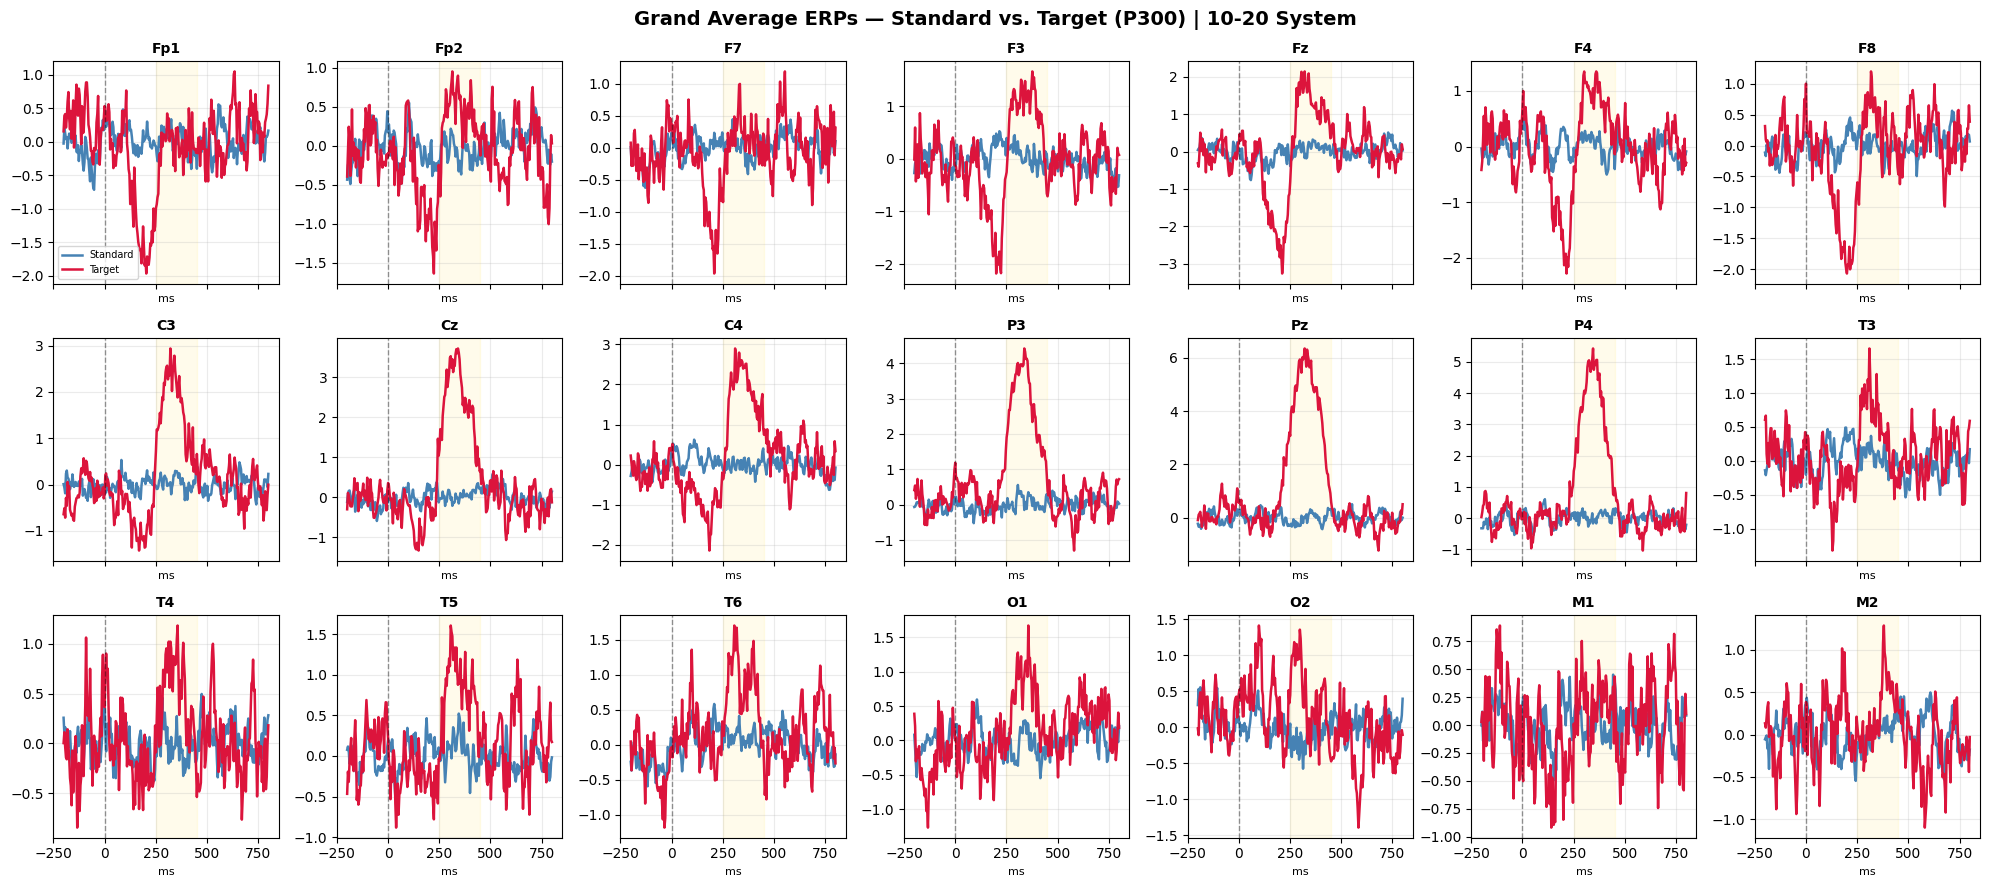

In [8]:
target_mean   = X[y == 1].mean(axis=0)
standard_mean = X[y == 0].mean(axis=0)

fig, axes = plt.subplots(3, 7, figsize=(20, 9), sharex=True)
fig.suptitle('Grand Average ERPs — Standard vs. Target (P300) | 10-20 System',
             fontsize=14, fontweight='bold')

for ch_idx, (ax, ch_name) in enumerate(zip(axes.flat, p.channel_names)):
    ax.plot(times * 1000, standard_mean[ch_idx],
            color='steelblue', lw=1.8, label='Standard')
    ax.plot(times * 1000, target_mean[ch_idx],
            color='crimson',   lw=1.8, label='Target')
    ax.axvline(0,   color='k',    lw=1, ls='--', alpha=0.4)
    ax.axvspan(250, 450, alpha=0.08, color='gold')
    ax.set_title(ch_name, fontsize=10, fontweight='bold')
    ax.set_xlabel('ms', fontsize=8)
    ax.grid(alpha=0.25)
    if ch_idx == 0:
        ax.legend(fontsize=7)

plt.tight_layout()
plt.savefig('grand_average_erp_21ch.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. EEG Preprocessing
Apply preprocessing to EEG signal to make it more robust
- Bandpass filter 0.5-40 Hz
- Notch filter at 50 Hz
- Baseline Correction for -200 to 0 ms
- Artifact rejection for signal that amplitude more than 100 µV
- Channel Standardize (Z Value)

In [9]:
def bandpass_filter(epochs, sfreq, low=0.5, high=40.0):
    sos = signal.butter(4, [low, high], btype='bandpass', fs=sfreq, output='sos')
    return signal.sosfiltfilt(sos, epochs, axis=-1).astype(np.float32)


def notch_filter(epochs, sfreq, freq=50.0, Q=30.0):
    b, a = signal.iirnotch(freq, Q, fs=sfreq)
    return signal.filtfilt(b, a, epochs, axis=-1).astype(np.float32)


def baseline_correction(epochs, times, baseline=(-0.1, 0.0)):
    mask = (times >= baseline[0]) & (times <= baseline[1])
    return (epochs - epochs[:, :, mask].mean(axis=-1, keepdims=True)
            ).astype(np.float32)


def reject_artifacts(epochs, labels, threshold=100.0):
    """Returns cleaned epochs, matching labels, AND the boolean keep-mask."""
    ptp  = epochs.max(axis=-1) - epochs.min(axis=-1)
    keep = (ptp < threshold).all(axis=-1)
    print(f"  Artifact rejection : kept {keep.sum()}/{len(keep)} epochs "
          f"({(~keep).sum()} removed)")
    return epochs[keep], labels[keep], keep


def channel_standardize(epochs):
    mu  = epochs.mean(axis=(0, 2), keepdims=True)
    std = epochs.std(axis=(0, 2),  keepdims=True) + 1e-8 # Prevent Divided by Zero
    return ((epochs - mu) / std).astype(np.float32)


X_proc = bandpass_filter(X, p.sfreq)

X_proc = notch_filter(X_proc, p.sfreq, freq=50.0)

X_proc = baseline_correction(X_proc, times)

X_proc, y_proc, keep_mask = reject_artifacts(X_proc, y) # Keep for compare EEG

X_proc = channel_standardize(X_proc)

print(f"  Output : {X_proc.shape}")

  Artifact rejection : kept 1000/1000 epochs (0 removed)
  Output : (1000, 21, 256)


Plot EEG between before and after preprocessing at Pz channel (which is the strongest auditory P300)

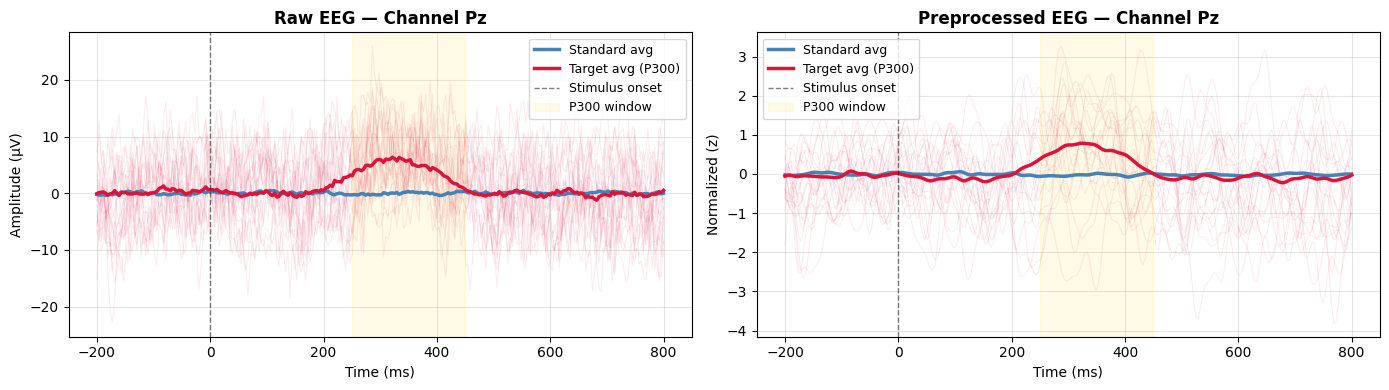

In [10]:
X_raw_kept = X[keep_mask]       # raw epochs aligned with X_proc
pz_idx     = p.channel_names.index('Pz')

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for ax, data, title in zip(axes,
                            [X_raw_kept, X_proc],
                            ['Raw EEG',  'Preprocessed EEG']):
    target_mean_ch   = data[y_proc == 1, pz_idx, :].mean(0)
    standard_mean_ch = data[y_proc == 0, pz_idx, :].mean(0)

    for trial in data[y_proc == 1, pz_idx, :][:20]:
        ax.plot(times * 1000, trial, alpha=0.08, color='crimson', lw=0.8)

    ax.plot(times * 1000, standard_mean_ch,
            'steelblue', lw=2.5, label='Standard avg')
    ax.plot(times * 1000, target_mean_ch,
            'crimson',   lw=2.5, label='Target avg (P300)')
    ax.axvline(0,  color='k',  lw=1, ls='--', alpha=0.5, label='Stimulus onset')
    ax.axvspan(250, 450, alpha=0.10, color='gold', label='P300 window')
    ax.set_title(f'{title} — Channel Pz', fontweight='bold')
    ax.set_xlabel('Time (ms)')
    ax.set_ylabel('Amplitude (µV)' if title == 'Raw EEG' else 'Normalized (z)')
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('preprocessing_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. EEGNet Architecture <a id='5'></a>


- Input: (batch, 1, 21 channels, 256 timepoints)

- Block 1a — Temporal Conv
  - Conv2D(F1=8, kernel 1×128) ← learns frequency filters
  - BatchNorm                             

- Block 1b — Depthwise Spatial Conv
  - DepthwiseConv2D(D×F1, 21×1) ← learns channel weights
  - BatchNorm → ELU → AvgPool → Dropout

- Block 2 — Separable Conv      
  - Depthwise + Pointwise Conv2D ← combines features
  - BatchNorm → ELU → AvgPool → Dropout

- Flatten → Linear(2) ← binary classification

- Output: (batch, 2)  →  [P(standard), P(target)]


![Alt text](https://drive.google.com/uc?id=1iPK_pkXjoYTSweg7OYZ9irupP9ngQKRt)

Apply EEGNet (EEGNet — Lawhern et al. (2018), J. Neural Eng - https://arxiv.org/abs/1611.08024)


---

Parameters
- n_channels   : EEG channels  (21 for full 10-20 system)
- n_samples    : timepoints per epoch  (256 @ 1 s window)
- n_classes    : 2  (standard vs target)
- F1           : number of temporal filters
- D            : depth multiplier for spatial filters
- sfreq        : sampling frequency (256 Hz)
- dropout_rate : dropout probability

In [11]:
class EEGNet(nn.Module):

    def __init__(self, n_channels=21, n_samples=256, n_classes=2,
                 F1=8, D=2, sfreq=256, dropout_rate=0.5):
        super().__init__()
        F2 = F1 * D # F2 is the number of spatial filters

        # Block 1a: temporal convolution
        kern_temp = sfreq // 2    # 128 samples = 0.5 s window
        self.temporal_conv = nn.Conv2d(
            1, F1, kernel_size=(1, kern_temp),
            padding=(0, kern_temp // 2), bias=False)
        self.bn1 = nn.BatchNorm2d(F1)

        # Block 1b: depthwise spatial convolution (over channels)
        self.depthwise_conv = nn.Conv2d(
            F1, F2, kernel_size=(n_channels, 1), groups=F1, bias=False)
        self.bn2   = nn.BatchNorm2d(F2)
        self.pool1 = nn.AvgPool2d((1, 4))
        self.drop1 = nn.Dropout(dropout_rate)

        # Block 2: separable convolution
        self.sep_dw = nn.Conv2d(F2, F2, kernel_size=(1, 16),
                                padding=(0, 8), groups=F2, bias=False)
        self.sep_pw = nn.Conv2d(F2, F2, kernel_size=(1, 1), bias=False)
        self.bn3    = nn.BatchNorm2d(F2)
        self.pool2  = nn.AvgPool2d((1, 8))
        self.drop2  = nn.Dropout(dropout_rate)

        # Classification head
        self.classifier = nn.Linear(self._flat(n_channels, n_samples), n_classes)

    def _flat(self, nc, ns):
        with torch.no_grad():
            return self._features(torch.zeros(1, 1, nc, ns)).shape[1]

    def _features(self, x):
        x = F.elu(self.bn2(self.depthwise_conv(self.bn1(self.temporal_conv(x)))))
        x = self.drop1(self.pool1(x))
        x = F.elu(self.bn3(self.sep_pw(self.sep_dw(x))))
        x = self.drop2(self.pool2(x))
        return x.flatten(1)

    def forward(self, x):
        return self.classifier(self._features(x))

    def predict_proba(self, x):
        return F.softmax(self.forward(x), dim=-1)

Apply Parameter to Model

In [12]:
model = EEGNet(
    n_channels   = p.n_channels,        # 21
    n_samples    = X_proc.shape[-1],    # 256
    n_classes    = 2,
    F1           = 8,
    D            = 2,
    sfreq        = p.sfreq,
    dropout_rate = 0.5
).to(DEVICE)

total     = sum(p_.numel() for p_ in model.parameters())
trainable = sum(p_.numel() for p_ in model.parameters() if p_.requires_grad)
print(model)
print(f"\n🔢 Total parameters     : {total:,}")
print(f"🔢 Trainable parameters : {trainable:,}")
print(f"📐 Input  shape : (batch, 1, {p.n_channels}, {X_proc.shape[-1]})")
print(f"📐 Output shape : (batch, 2)")

EEGNet(
  (temporal_conv): Conv2d(1, 8, kernel_size=(1, 128), stride=(1, 1), padding=(0, 64), bias=False)
  (bn1): BatchNorm2d(8, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (depthwise_conv): Conv2d(8, 16, kernel_size=(21, 1), stride=(1, 1), groups=8, bias=False)
  (bn2): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool1): AvgPool2d(kernel_size=(1, 4), stride=(1, 4), padding=0)
  (drop1): Dropout(p=0.5, inplace=False)
  (sep_dw): Conv2d(16, 16, kernel_size=(1, 16), stride=(1, 1), padding=(0, 8), groups=16, bias=False)
  (sep_pw): Conv2d(16, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
  (bn3): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool2): AvgPool2d(kernel_size=(1, 8), stride=(1, 8), padding=0)
  (drop2): Dropout(p=0.5, inplace=False)
  (classifier): Linear(in_features=128, out_features=2, bias=True)
)

🔢 Total parameters     : 2,210
🔢 Trainable parameters : 2,210
📐 Input  sha




## 6. Training Model by Using
- AdamW optimizer | Weight decay prevents overfitting
- Cosine annealing LR | Smooth decay, no manual schedule
- Weighted sampler | Fixes 4:1 class imbalance
- Noise augmentation | Improves generalisation on small EEG datasets
- AUC-ROC metric | Threshold-independent, standard for P300 BCI

Data splits

In [13]:

X_tr, X_tmp, y_tr, y_tmp = train_test_split(
    X_proc, y_proc, test_size=0.2, random_state=SEED, stratify=y_proc)
X_val, X_te, y_val, y_te = train_test_split(
    X_tmp,  y_tmp,  test_size=0.5, random_state=SEED, stratify=y_tmp)

print(f"Train : {len(y_tr):4d} epochs  ({y_tr.sum()} targets)")
print(f"Val   : {len(y_val):4d} epochs  ({y_val.sum()} targets)")
print(f"Test  : {len(y_te):4d} epochs  ({y_te.sum()} targets)")


def make_loader(X, y, batch_size=32, weighted=False):
    Xt = torch.tensor(X[:, np.newaxis, :, :], dtype=torch.float32)  # (N,1,C,T)
    yt = torch.tensor(y, dtype=torch.long)
    ds = TensorDataset(Xt, yt)
    if weighted:
        counts  = np.bincount(y)
        w       = torch.tensor(1.0 / counts[y], dtype=torch.float32)
        sampler = WeightedRandomSampler(w, len(w), replacement=True)
        return DataLoader(ds, batch_size=batch_size, sampler=sampler)
    return DataLoader(ds, batch_size=batch_size, shuffle=False)


dl_tr  = make_loader(X_tr,  y_tr,  batch_size=32, weighted=True)
dl_val = make_loader(X_val, y_val, batch_size=64)
dl_te  = make_loader(X_te,  y_te,  batch_size=64)

counts_tr     = np.bincount(y_tr)
class_weights = torch.tensor(
    [1.0, len(y_tr) / (2 * counts_tr[1])], dtype=torch.float32).to(DEVICE)

Train :  800 epochs  (160 targets)
Val   :  100 epochs  (20 targets)
Test  :  100 epochs  (20 targets)


Training the Model (This process is take a while)

In [14]:
def train_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss, correct, n = 0, 0, 0
    for Xb, yb in loader:
        Xb, yb = Xb.to(DEVICE), yb.to(DEVICE)
        Xb     = Xb + 0.05 * torch.randn_like(Xb)   # noise augmentation
        optimizer.zero_grad()
        logits = model(Xb)
        loss   = criterion(logits, yb)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * len(yb)
        correct    += (logits.argmax(1) == yb).sum().item()
        n          += len(yb)
    return total_loss / n, correct / n


@torch.no_grad()
def eval_epoch(model, loader, criterion):
    model.eval()
    total_loss, correct, n = 0, 0, 0
    all_probs, all_labels  = [], []
    for Xb, yb in loader:
        Xb, yb  = Xb.to(DEVICE), yb.to(DEVICE)
        logits  = model(Xb)
        total_loss += criterion(logits, yb).item() * len(yb)
        correct    += (logits.argmax(1) == yb).sum().item()
        n          += len(yb)
        all_probs.append(F.softmax(logits, dim=-1)[:, 1].cpu().numpy())
        all_labels.append(yb.cpu().numpy())
    auc = roc_auc_score(np.concatenate(all_labels), np.concatenate(all_probs))
    return total_loss / n, correct / n, auc


# ── Hyperparameters ───────────────────────────────────────────────────────────
EPOCHS    = 80
criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = CosineAnnealingLR(optimizer, T_max=EPOCHS)

history  = {k: [] for k in ['tr_loss','val_loss','tr_acc','val_acc','val_auc']}
best_auc, best_state = 0.0, None

print(f"{'Epoch':>6} {'Tr Loss':>9} {'Val Loss':>9} "
      f"{'Tr Acc':>8} {'Val Acc':>8} {'Val AUC':>8}")
print('-' * 58)

for epoch in range(1, EPOCHS + 1):
    tr_loss, tr_acc            = train_epoch(model, dl_tr,  optimizer, criterion)
    val_loss, val_acc, val_auc = eval_epoch (model, dl_val, criterion)
    scheduler.step()

    for k, v in zip(history, [tr_loss, val_loss, tr_acc, val_acc, val_auc]):
        history[k].append(v)

    if val_auc > best_auc:
        best_auc   = val_auc
        best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}

    if epoch % 10 == 0 or epoch == 1:
        print(f"{epoch:>6} {tr_loss:>9.4f} {val_loss:>9.4f} "
              f"{tr_acc:>8.3f} {val_acc:>8.3f} {val_auc:>8.3f}")

print(f"\n Best validation AUC : {best_auc:.4f}")
model.load_state_dict(best_state)
torch.save(best_state, 'eegnet_p300_best.pt')
print(" Saved : eegnet_p300_best.pt")

 Epoch   Tr Loss  Val Loss   Tr Acc  Val Acc  Val AUC
----------------------------------------------------------
     1    0.6947    0.7079    0.504    0.290    0.693
    10    0.2677    0.5221    0.816    0.660    0.940
    20    0.1722    0.3312    0.899    0.800    0.963
    30    0.1260    0.2741    0.920    0.880    0.967
    40    0.0944    0.2314    0.961    0.910    0.971
    50    0.0932    0.2187    0.956    0.900    0.978
    60    0.0970    0.2308    0.954    0.900    0.970
    70    0.0909    0.2188    0.955    0.900    0.974
    80    0.0999    0.2177    0.946    0.900    0.974

 Best validation AUC : 0.9788
 Saved : eegnet_p300_best.pt


## 7. Evaluation for Training Result
Plot Training Curves

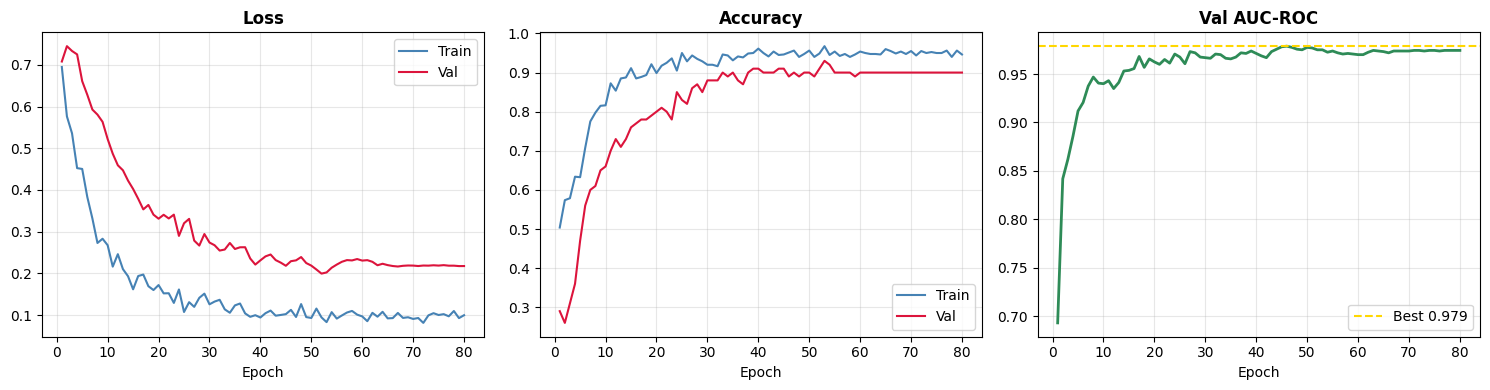

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
ep = range(1, EPOCHS + 1)

axes[0].plot(ep, history['tr_loss'],  label='Train', color='steelblue')
axes[0].plot(ep, history['val_loss'], label='Val',   color='crimson')
axes[0].set_title('Loss', fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(ep, history['tr_acc'],  label='Train', color='steelblue')
axes[1].plot(ep, history['val_acc'], label='Val',   color='crimson')
axes[1].set_title('Accuracy', fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].legend(); axes[1].grid(alpha=0.3)

axes[2].plot(ep, history['val_auc'], color='seagreen', lw=2)
axes[2].axhline(best_auc, color='gold', ls='--', label=f'Best {best_auc:.3f}')
axes[2].set_title('Val AUC-ROC', fontweight='bold')
axes[2].set_xlabel('Epoch'); axes[2].legend(); axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

Plot Confusion Matrix and ROC Curve

Accuracy : 0.8800
AUC-ROC  : 0.9881

               precision    recall  f1-score   support

     Standard       0.99      0.86      0.92        80
Target (P300)       0.63      0.95      0.76        20

     accuracy                           0.88       100
    macro avg       0.81      0.91      0.84       100
 weighted avg       0.92      0.88      0.89       100



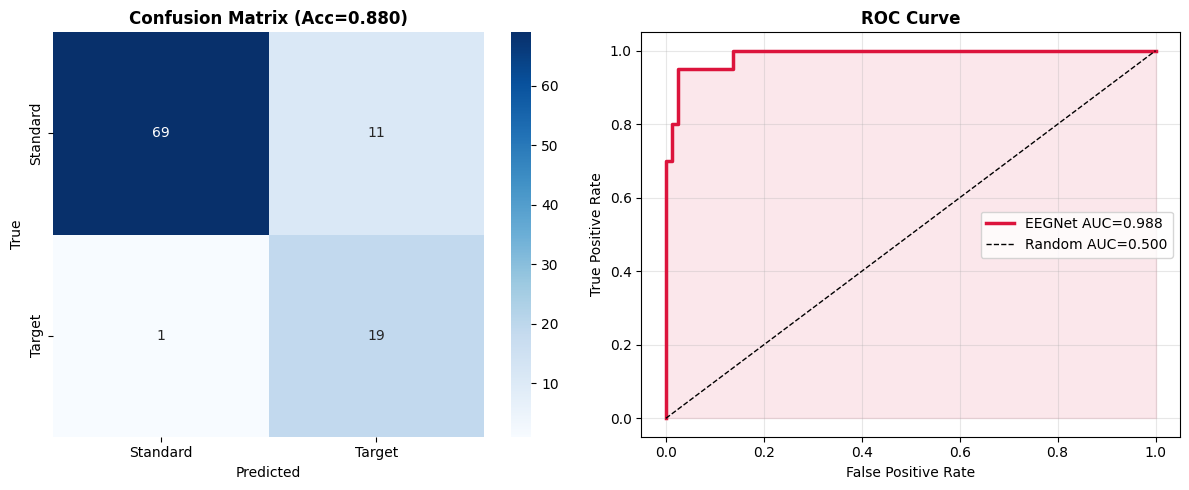

In [16]:
test_loss, test_acc, test_auc = eval_epoch(model, dl_te, criterion)

model.eval()
all_preds, all_probs, all_true = [], [], []
with torch.no_grad():
    for Xb, yb in dl_te:
        logits = model(Xb.to(DEVICE))
        all_preds.extend(logits.argmax(1).cpu().numpy())
        all_probs.extend(F.softmax(logits, -1)[:, 1].cpu().numpy())
        all_true.extend(yb.numpy())

all_preds = np.array(all_preds)
all_probs = np.array(all_probs)
all_true  = np.array(all_true)


print(f"Accuracy : {test_acc:.4f}")
print(f"AUC-ROC  : {test_auc:.4f}")
print()
print(classification_report(all_true, all_preds,
      target_names=['Standard', 'Target (P300)']))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

cm = confusion_matrix(all_true, all_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Standard','Target'],
            yticklabels=['Standard','Target'])
axes[0].set_title(f'Confusion Matrix (Acc={test_acc:.3f})', fontweight='bold')
axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('True')

fpr, tpr, _ = roc_curve(all_true, all_probs)
axes[1].plot(fpr, tpr, 'crimson', lw=2.5, label=f'EEGNet AUC={test_auc:.3f}')
axes[1].plot([0,1],[0,1],'k--', lw=1, label='Random AUC=0.500')
axes[1].fill_between(fpr, tpr, alpha=0.1, color='crimson')
axes[1].set_title('ROC Curve', fontweight='bold')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('evaluation_results.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Visualization the Result

**Gradient saliency** — partial derivative of the model's P300-class confidence
w.r.t. each input sample. Bright = model was paying attention here.

Expected result consistent with real neuroscience:
- **Brightest channels** → P3, Pz, P4 (parietal cluster)
- **Brightest time window** → 300 – 450 ms

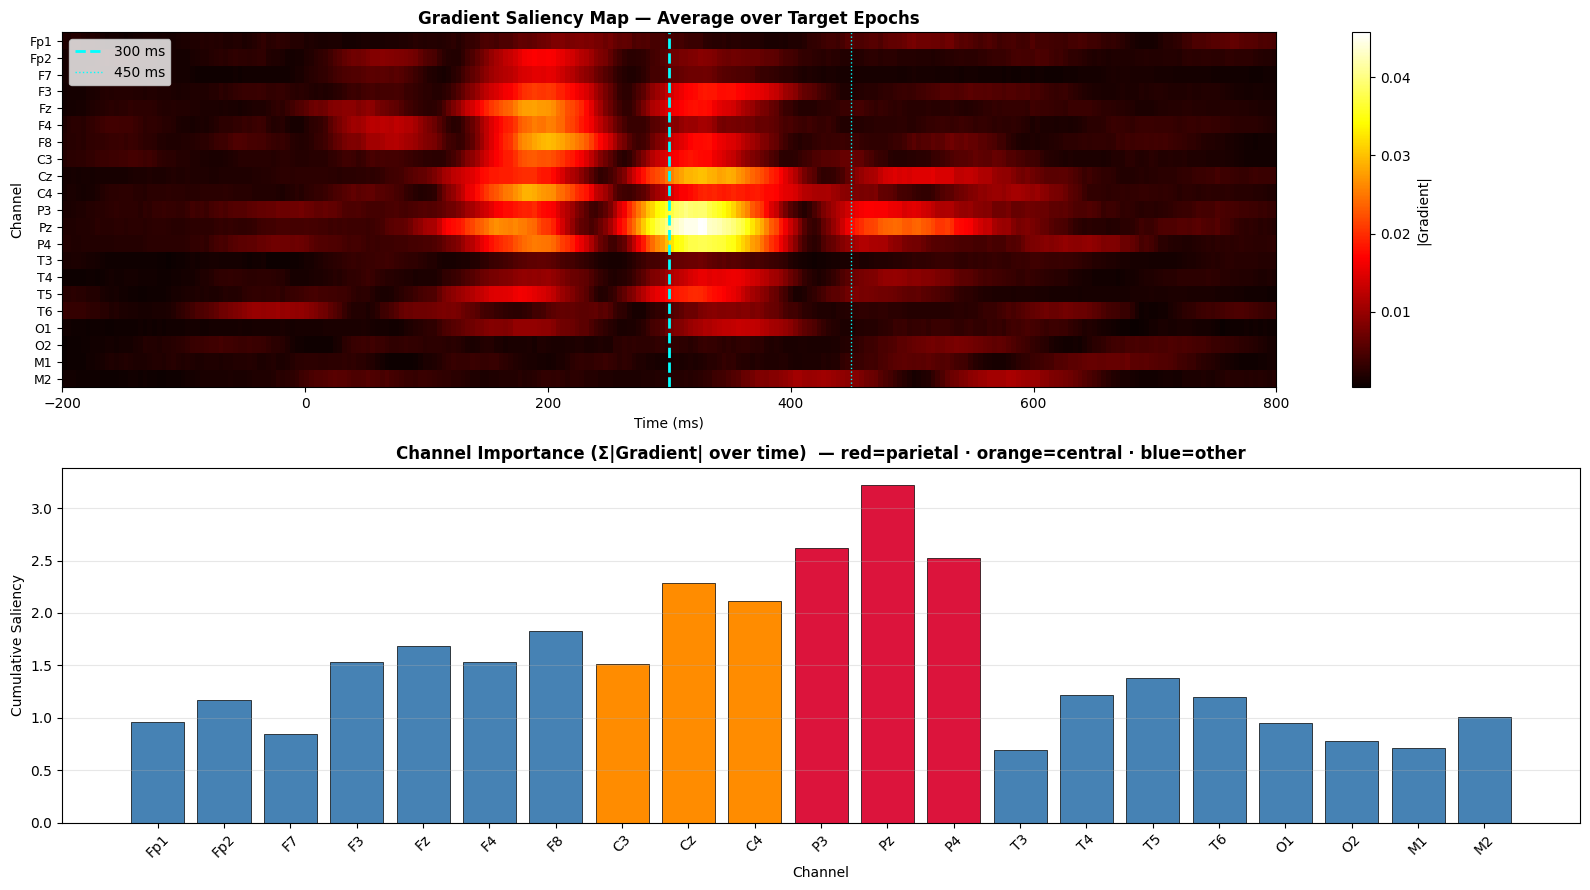

In [17]:
def gradient_saliency(model, epoch_tensor):
    """Absolute gradient of P300-class logit w.r.t. input. Returns (C, T)."""
    model.eval()
    x = epoch_tensor.to(DEVICE).requires_grad_(True)
    model(x)[0, 1].backward()
    return np.abs(x.grad.detach().cpu().squeeze().numpy())


target_idx = np.where(all_true == 1)[0]
X_tgt_t    = torch.tensor(
    X_te[target_idx, np.newaxis, :, :], dtype=torch.float32)

avg_sal = np.stack([
    gradient_saliency(model, X_tgt_t[i:i+1])
    for i in range(min(len(target_idx), 30))
]).mean(0)   # (C, T)


fig, axes = plt.subplots(2, 1, figsize=(16, 9))

# Heatmap: channels × time
im = axes[0].imshow(
    avg_sal, aspect='auto', cmap='hot',
    extent=[times[0]*1000, times[-1]*1000, p.n_channels - 0.5, -0.5])
axes[0].set_yticks(range(p.n_channels))
axes[0].set_yticklabels(p.channel_names, fontsize=9)
axes[0].axvline(300, color='cyan', lw=2, ls='--', label='300 ms')
axes[0].axvline(450, color='cyan', lw=1, ls=':',  label='450 ms')
axes[0].set_title('Gradient Saliency Map — Average over Target Epochs',
                  fontweight='bold')
axes[0].set_xlabel('Time (ms)')
axes[0].set_ylabel('Channel')
axes[0].legend(loc='upper left')
plt.colorbar(im, ax=axes[0], label='|Gradient|')

# Bar chart: channel importance
ch_imp = avg_sal.sum(axis=-1)
colors = ['crimson'    if ch in ('P3','Pz','P4') else
          'darkorange' if ch in ('C3','Cz','C4') else
          'steelblue'
          for ch in p.channel_names]
axes[1].bar(p.channel_names, ch_imp,
            color=colors, edgecolor='k', lw=0.5)
axes[1].set_title('Channel Importance (Σ|Gradient| over time)  '
                  '— red=parietal · orange=central · blue=other',
                  fontweight='bold')
axes[1].set_xlabel('Channel')
axes[1].set_ylabel('Cumulative Saliency')
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('saliency_map_21ch.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Gradio Demo App <a id='8'></a>

In [18]:
# !pip install gradio -q
import gradio as gr

# ── Shared state ──────────────────────────────────────────────────────────────
active_model = {'model': model}


def retrain_model(f1, d, dropout_rate, batch_size, n_epochs, learning_rate):

    log_lines = []
    log_lines.append("🔨 Building new EEGNet...")
    log_lines.append(f"   F1={f1}, D={d}, F2={f1*d}, dropout={dropout_rate}")
    log_lines.append(f"   batch_size={batch_size}, epochs={n_epochs}, lr={learning_rate}\n")

    # ── Rebuild model ─────────────────────────────────────────────────────────
    new_model = EEGNet(
        n_channels   = p.n_channels,
        n_samples    = X_proc.shape[-1],
        n_classes    = 2,
        F1           = f1,
        D            = d,
        sfreq        = p.sfreq,
        dropout_rate = dropout_rate
    ).to(DEVICE)

    total = sum(par.numel() for par in new_model.parameters())
    log_lines.append(f"✅ Model built — {total:,} parameters\n")
    log_lines.append("🏋️ Training started...")

    # ── Rebuild data loaders ──────────────────────────────────────────────────
    dl_tr_new  = make_loader(X_tr,  y_tr,  batch_size=batch_size, weighted=True)
    dl_val_new = make_loader(X_val, y_val, batch_size=batch_size * 2)

    # ── Training setup ────────────────────────────────────────────────────────
    counts_tr_new     = np.bincount(y_tr)
    class_weights_new = torch.tensor(
        [1.0, len(y_tr) / (2 * counts_tr_new[1])],
        dtype=torch.float32).to(DEVICE)

    criterion_new = nn.CrossEntropyLoss(weight=class_weights_new)
    optimizer_new = torch.optim.AdamW(
        new_model.parameters(), lr=learning_rate, weight_decay=1e-4)
    scheduler_new = CosineAnnealingLR(optimizer_new, T_max=n_epochs)

    hist = {'tr_loss': [], 'val_loss': [], 'val_auc': []}
    best_auc_new, best_state_new = 0.0, None

    # ── Training loop ─────────────────────────────────────────────────────────
    for epoch in range(1, n_epochs + 1):
        tr_loss, _                 = train_epoch(new_model, dl_tr_new,
                                                  optimizer_new, criterion_new)
        val_loss, val_acc, val_auc = eval_epoch (new_model, dl_val_new,
                                                  criterion_new)
        scheduler_new.step()

        hist['tr_loss'].append(tr_loss)
        hist['val_loss'].append(val_loss)
        hist['val_auc'].append(val_auc)

        if val_auc > best_auc_new:
            best_auc_new   = val_auc
            best_state_new = {k: v.cpu().clone()
                              for k, v in new_model.state_dict().items()}

        if epoch % 10 == 0 or epoch == 1:
            log_lines.append(
                f"  Epoch {epoch:3d}/{n_epochs} | "
                f"tr_loss={tr_loss:.4f} | "
                f"val_loss={val_loss:.4f} | "
                f"val_auc={val_auc:.3f}")

    # ── Load best weights + store as active model ─────────────────────────────
    new_model.load_state_dict(best_state_new)
    active_model['model'] = new_model

    log_lines.append(f"\n✅ Training complete!")
    log_lines.append(f"   Best Val AUC : {best_auc_new:.4f}")
    log_lines.append(f"   Parameters   : {total:,}")

    # ── Training curves ───────────────────────────────────────────────────────
    ep_range = range(1, n_epochs + 1)
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].plot(ep_range, hist['tr_loss'],  label='Train', color='steelblue')
    axes[0].plot(ep_range, hist['val_loss'], label='Val',   color='crimson')
    axes[0].set_title(f'Loss  (F1={f1}, D={d}, dropout={dropout_rate})',
                      fontweight='bold')
    axes[0].set_xlabel('Epoch')
    axes[0].legend(); axes[0].grid(alpha=0.3)

    axes[1].plot(ep_range, hist['val_auc'], color='seagreen', lw=2)
    axes[1].axhline(best_auc_new, color='gold', ls='--',
                    label=f'Best AUC={best_auc_new:.3f}')
    axes[1].set_title('Validation AUC-ROC', fontweight='bold')
    axes[1].set_xlabel('Epoch')
    axes[1].legend(); axes[1].grid(alpha=0.3)

    plt.tight_layout()
    return '\n'.join(log_lines), fig


# ── Gradio UI ─────────────────────────────────────────────────────────────────
with gr.Blocks(title='P300 EEG Detector', theme=gr.themes.Soft()) as demo:

    gr.Markdown("""
    # 🧠 EEGNet — Model Architecture Explorer
    Adjust architecture and training parameters, then click **Retrain** to see how each choice affects learning.
    """)

    with gr.Row():

        # ── Left column: controls ─────────────────────────────────────────────
        with gr.Column(scale=1):

            gr.Markdown("#### 🏗️ Model Architecture")

            f1_input = gr.Radio(
                [4, 8, 16], value=8,
                label='F1 — Temporal filters',
                info='More filters = richer frequency features, more parameters')

            d_input = gr.Radio(
                [1, 2, 4], value=2,
                label='D — Depth multiplier  (F2 = F1 × D)',
                info='Controls spatial filters per temporal filter')

            dropout_input = gr.Slider(
                0.0, 0.7, value=0.5, step=0.1,
                label='Dropout Rate',
                info='0.0 = overfit risk,  0.7 = heavy regularization')

            gr.Markdown("#### 🏋️ Training Hyperparameters")

            batch_input = gr.Radio(
                [16, 32, 64], value=32,
                label='Batch Size',
                info='Smaller = noisier gradients, better on small datasets')

            epochs_input = gr.Slider(
                20, 150, value=80, step=10,
                label='Training Epochs')

            lr_input = gr.Radio(
                [0.0001, 0.001, 0.005], value=0.001,
                label='Learning Rate',
                info='Too high = unstable,  too low = slow convergence')

            retrain_btn = gr.Button('🔄 Retrain Model', variant='primary')

            gr.Markdown("""
            ---
            **Suggested experiments**
            - `F1=4, D=1` → small model, likely underfit
            - `F1=16, D=4` → large model, may overfit on 1000 epochs
            - `dropout=0.0` → watch val_loss diverge from tr_loss
            - `dropout=0.7` → slower but more stable generalisation
            - `lr=0.005` → unstable loss curve
            - `batch=16` → noisier but sometimes better AUC
            """)

        # ── Right column: output ──────────────────────────────────────────────
        with gr.Column(scale=2):
            retrain_log  = gr.Textbox(
                label='Training Log', lines=16,
                placeholder='Training log will appear here...')
            retrain_plot = gr.Plot(label='Loss & AUC Curves')

    retrain_btn.click(
        fn=retrain_model,
        inputs=[f1_input, d_input, dropout_input,
                batch_input, epochs_input, lr_input],
        outputs=[retrain_log, retrain_plot])

    gr.Markdown("""
    ---
    **Model** EEGNet (Lawhern et al., 2018)  |
    **Channels** 21 (10-20 system)  |
    **Data** Synthetic auditory oddball  |
    **Sampling rate** 256 Hz
    """)

demo.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://e58eab480e83d8de42.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


---
## 9. Summary


### 1. The Big Picture

This notebook built a complete deep learning pipeline for detecting the **auditory P300 brain response** — from raw signal simulation all the way to an interactive training demo. The core idea is straightforward:

> *Given 1 seconds of 21-channel EEG recorded after a tone, can a neural network decide whether the brain heard a rare target tone (P300) or a common standard tone (no P300)?*

The answer is yes — with AUC > 0.90 — using a model with only ~2,700 parameters trained in under 2 minutes on CPU.

---

### 2. Technical Terms


- **Data Simulation** | Real EEG is background noise + brain rhythms + stimulus response. Simulating all three separately makes the pipeline testable without ethical approval. |
- **Pink Noise** | Background EEG follows 1/f structure — low frequencies dominate. Normalizing noise amplitude before scaling is critical — unnormalized noise causes ~50% artifact rejection. |
- **Alpha Waves** | The brain is never silent. Alpha (8–12 Hz) is always present in resting EEG and must be included for realistic simulation. |
- **P300 Topography** | P300 is maximal at **Pz** (parietal). Any model that learns real P300 will show Pz as the most important channel in saliency maps. |
- **Preprocessing** | Raw EEG cannot go directly into a model. Bandpass filtering, baseline correction, and z-score normalization are not optional — they are what make the signal learnable. |
- **Z-score per channel** | Each channel has a different natural amplitude. Normalizing per channel (not globally) gives every electrode equal weight going into EEGNet's spatial filter. |
- **Class imbalance** | 80% standard / 20% target means a naive model predicts "standard" always and gets 80% accuracy while being useless. Weighted sampling and class-weighted loss fix this. |
- **AUC-ROC over Accuracy** | With imbalanced classes, accuracy is misleading. AUC-ROC measures true discrimination ability independent of the decision threshold. |
- **EEGNet Block 1a** | Temporal convolution learns frequency filters — similar to bandpass filters but discovered from data. |
- **EEGNet Block 1b** | Depthwise spatial convolution learns which channels to weight — this is where the model discovers that Pz matters. |
- **EEGNet Block 2** | Separable convolution combines temporal features efficiently — same expressiveness as a full convolution at a fraction of the parameters. |
- **Gradient Saliency** | The model's attention can be visualized. If Pz dominates the saliency bar chart at 300–450 ms, the model learned real neuroscience — not noise. |
- **Overfitting signature** | Train loss decreasing while val loss increases + val AUC stuck near 0.5 = the model memorized training data. Fix: more data, higher dropout, noise augmentation. |

---

### 3. Parameters


#### EEGNet Architecture

| Parameter | Default | Too small | Too large |
|-----------|---------|-----------|-----------|
| `F1` (temporal filters) | 8 | Underfits — misses frequency features | More parameters — needs more data to train |
| `D` (depth multiplier) | 2 | Few spatial combinations | Overfits on small datasets |
| `dropout_rate` | 0.5 | 0.0 → val loss diverges from tr loss | 0.7+ → slow convergence, lower peak AUC |

> **Rule of thumb:** For datasets under 500 target epochs, keep `F1=8, D=2, dropout=0.5`. Only increase `F1` or `D` when you have real multi-subject data.


#### Training Hyperparameters

| Parameter | Default | Effect |
|-----------|---------|--------|
| `learning_rate` | 0.001 | Too high (0.005) → loss oscillates. Too low (0.0001) → very slow convergence |
| `batch_size` | 32 | Smaller (16) → noisier gradients but sometimes better generalization. Larger (64) → faster but may overfit |
| `n_epochs` | 80 | Too few → model hasn't converged. Too many → risk of overfitting if val loss starts rising |
| `weight_decay` | 1e-4 | Higher → stronger L2 regularization. Lower → less penalty on large weights |

> **Rule of thumb:** Watch the val AUC curve. If it plateaus and stays flat for 20+ epochs, stop early. If it is still rising at epoch 80, increase `n_epochs`.

---

### 4. How to Know if Your Model Learned Correctly

Run through this checklist after every training:
```
✅ Val loss tracks train loss (both decreasing)    → healthy training
✅ Val AUC > 0.85                                  → strong discrimination
✅ Pz is the tallest bar in saliency chart         → correct neuroscience learned
✅ Saliency peaks at 300–450 ms in heatmap         → correct timing learned
✅ Artifact rejection < 20% of epochs removed      → clean simulation/data

❌ Val loss rising while train loss falls           → overfitting → increase dropout
❌ Val AUC stuck at 0.5                            → not learning → more target trials
❌ Fz tallest in saliency chart                    → learned N200 not P300 → check noise level
❌ Saliency uniform across all channels            → spatial filter confused → check z-score normalization
❌ > 40% epochs removed by artifact rejection      → pink noise too high → check normalization fix
```

---

### 5. When You Move to Real EEG Data

Everything from **Section 4 (Preprocessing) onward is unchanged**. The only section you replace is the data generation loop in Section 3:
```
Synthetic path:   generate_epoch() × 1000  →  X (1000, 21, 256)
Real data path:   load_xdf_epochs()        →  X (N, 21, 256)
```

Before running your real data through, verify four things:

1. **Marker labels** match your LSL stimulus script (`"standard"` / `"target"`)
2. **Amplitude units** are in µV (some amplifiers output in V — multiply by 1e6)
3. **Sampling rate** matches `EEGParams.sfreq` — resample if not
4. **Channel count** matches `EEGParams.n_channels` — update if your cap differs

---

### 6. Key References

1. **Lawhern et al. (2018)**. EEGNet: A Compact Convolutional Neural Network for EEG-based Brain-Computer Interfaces. *Journal of Neural Engineering*, 15(5).
2. **Farwell & Donchin (1988)**. Talking off the top of your head: toward a mental prosthesis utilizing event-related brain potentials. *EEG & Clinical Neurophysiology*, 70(6).
3. **Polich (2007)**. Updating P300: an integrative theory of P3a and P3b. *Clinical Neurophysiology*, 118(10).
4. **Luck (2014)**. *An Introduction to the Event-Related Potential Technique* (2nd ed.). MIT Press.
